# 04 — Model 1: gas recommendation (NG flow + air-fuel ratio)

**What the operator gets.** One recommendation per 20-min reversal cycle, ready by minute 15 so it can be set in the minute 15–20 window. It contains:
- **NG flow**, in the same unit as the workbook column `dcs_60_MelterGasflowvalue…` (no conversion, per plant). One value for both inlets (common header).
- **Air-fuel ratio**, and the matching secondary air flow.

**Inputs**
| Input | Source | Frequency |
|---|---|---|
| NCV | automatic (UEMS) | every 15 min, latest value |
| Draw, cullet % | operator | daily |
| Optical crown temperature | operator | current reading: **guard-rail only** (flagged outside its historical band), not a model input |
| Barrier + melter boost | **read from the DB** (plant decision: gas runs every 15 min, boost is recommended hourly) | last hour |

**Method** (chosen in `notebooks/training/T1` and `T2`)
1. **Daily gas-heat target:**
   - an OLS model on **all past usable days**: `gas_Gcal ~ draw + barrier_Gcal + melter_Gcal + furnace age`
   - plus a **conformal shift**: the 25th percentile of the model's errors over the last 45 days
   - The result is the gas the efficient quarter of comparable recent days needed.
   - Previous-day optical was an input in the first-file version. With the corrected data it adds nothing (T1 §D) and it mis-calibrated September (§8), so it was removed. Both versions are shown below.
2. **Steady heat over the day.** No optical trim.
3. **NG = heat per 15 min ÷ latest NCV.** This is exact NCV compensation.
4. **Secondary air = air-per-Mcal target × heat**, and **AFR = secondary air ÷ NG**. The target is the P25 of the last 45 days, floored at the historical P5 (no O₂ analyser).
5. **Limits** = historical P1–P99. Back-tested with and without them.

**Data:** the corrected analytical record (`Analytical_Record_Creation_fixed_5.xlsx`).

**Back-test:** Jun–Aug 2026, walk-forward (each day only sees earlier days). **Sep 2026 is the validation month** (§8): its draw arrived with the corrected file, and no model choice was made on it.

In [1]:
import sys; sys.path.insert(0, '../src'); sys.path.insert(0, '../../src')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import data_prep as dp
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, INK2, MUTED, GRID, SURF = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURF, 'axes.facecolor': SURF, 'axes.edgecolor': MUTED,
    'axes.labelcolor': INK2, 'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.grid': True,
    'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'lines.linewidth': 1.6, 'font.size': 10, 'axes.titlesize': 11, 'axes.titlecolor': INK,
    'legend.frameon': False, 'figure.dpi': 110})
import recommender as rc
q = pd.read_parquet('../data/processed/ar_15min_clean.parquet')
h = pd.read_parquet('../data/processed/hourly_clean.parquet')
d = pd.read_parquet('../data/processed/daily_clean.parquet')
u = rc.prepare_gas_features(d[d.usable])
u['E_g'] = u.energy_kcal / 1e6
TEST_START, TEST_END = '2026-06-01', '2026-08-31'
test_days = u[(u.index >= TEST_START) & (u.index <= TEST_END)].index
print('usable days:', len(u), '| test days (Jun-Aug 2026):', len(test_days))

usable days: 343 | test days (Jun-Aug 2026): 85


## 1. Historical limits (P1–P99 of normal operation)

In [2]:
lim = rc.historical_limits(q, h)
LIMITS = {'ng_scm': tuple(lim.loc['ng_scm (per 15 min)', ['P1', 'P99']]), 'afr': tuple(lim.loc['afr', ['P1', 'P99']])}
lim.round(2)

,P1,median,P99
ng_scm (per 15 min),73.86,82.54,96.34
afr,10.99,12.17,13.44
air_per_mcal,1.20,1.27,1.34
bb_kwh (per hour),114.30,379.60,609.80
opt_temp (°C),1568.00,1575.00,1578.00
mb3_temp (°C),1316.14,1320.24,1325.56
crown_tc (°C),1559.17,1567.01,1573.75


## 2. The chosen target model vs the first version
Full model selection is in `notebooks/training/T1_gas_model_experiments.ipynb` (8 model types, 7 input sets, 2 test periods). Its summary is reloaded here. The chosen model is compared on Jun–Aug 2026 with the earlier version that also used previous-day optical, and with the first version (rolling 45-day quantile regression).

In [3]:
display(pd.read_csv(dp.PROCESSED / 'training_gas_final_variants.csv', index_col=0).round(3))
def pinball(y, p, t=0.25):
    e = y - p; return float(np.mean(np.maximum(t*e, (t-1)*e)))
te = u.loc[test_days]
tgt = rc.walk_forward_gas_targets(u, test_days)                                # chosen model
tgt_opt = rc.walk_forward_gas_targets(u, test_days, method='ols_conformal_opt')  # earlier version, + previous-day optical
tgt_old = rc.walk_forward_gas_targets(u, test_days, method='qr_rolling')         # first version
def target_scores(y, E, versions):
    return pd.DataFrame({m: {'pinball': pinball(y, t), 'share of days below target': (y <= t).mean(),
                             'MAE (Gcal/day)': (y - t).abs().mean(), 'implied energy saving %': 100*(y - t).sum()/E.sum()}
                         for m, t in versions}).T
target_scores(te.gas_g, te.E_g, [('chosen: OLS + ageing + conformal', tgt), ('earlier: + previous-day optical', tgt_opt),
                                 ('first version: rolling QR 45d', tgt_old)]).round(3)

,pinball,coverage_min,coverage_max,mae,saving_pct
variant,,,,,
"+ optical (same day, filled)",0.334,0.247,0.333,0.917,0.548
+ crown thermocouple MC3,0.337,0.200,0.278,0.945,0.595
winner (no crown temp),0.344,0.200,0.300,0.943,0.559
"+ optical (yesterday, filled)",0.344,0.200,0.289,0.952,0.576
final inputs without melter boost,0.345,0.212,0.289,0.951,0.572
without barrier boost,0.437,0.306,0.356,1.159,0.627


,pinball,share of days below target,MAE (Gcal/day),implied energy saving %
chosen: OLS + ageing + conformal,0.355,0.200,1.036,0.714
earlier: + previous-day optical,0.349,0.200,1.013,0.688
first version: rolling QR 45d,0.424,0.247,1.199,0.767


**Reading.** On Jun–Aug the earlier optical version is slightly more accurate (pinball 0.349 vs 0.355); both have the same realistic coverage. The first version (rolling QR) is clearly less accurate. The deciding test is September (§8): there the optical version fails its calibration and the chosen model doesn't.

In [4]:
fin = smf.ols(rc.GAS_FORMULA, u[u.index < TEST_START].dropna(subset=rc.GAS_FEATURES)).fit()
print('Model fitted on data before the test period (Gcal/day):'); print(fin.params.round(3).to_dict())
print('-> +1 t/day draw: %+.2f Gcal/day gas | +1 Gcal/day barrier boost: %+.2f | +1 Gcal/day melter boost: %+.2f | +1 month age: %+.2f' % (
      fin.params.draw_t, fin.params.bb_g, fin.params.mb_g, fin.params.age_m))

Model fitted on data before the test period (Gcal/day):
{'Intercept': 53.036, 'draw_t': 0.483, 'bb_g': -0.727, 'mb_g': -0.136, 'age_m': 0.293}
-> +1 t/day draw: +0.48 Gcal/day gas | +1 Gcal/day barrier boost: -0.73 | +1 Gcal/day melter boost: -0.14 | +1 month age: +0.29


## 3. Is the frontier safe? Check the days that already ran at or below it
If days that used ≤ target gas had worse temperatures or quality, the target would be risky. Compare those days with the rest of the test period.

In [5]:
te = u.loc[test_days].copy(); te['target'] = tgt
te['at_or_below'] = te.gas_g <= te.target
chk = te.groupby('at_or_below')[['crown_tc', 'mb3_temp', 'opt_temp', 'seed_count', 'draw_t', 'bb_kwh']].mean()
chk.index = ['above target', 'at/below target']
chk.round(2)

,crown_tc,mb3_temp,opt_temp,seed_count,draw_t,bb_kwh
above target,1566.32,1321.99,1574.37,16.44,57.65,8724.36
at/below target,1566.39,1320.85,1574.72,14.53,55.36,7428.17


Days that already ran at or below the target had the same crown and bottom temperatures and no more seeds. So the frontier is operation the furnace has already shown it can do safely in the current conditions.

## 4. Within-day: steady heat, exact NCV compensation, secondary air first
- The day's target is spread evenly over 96 intervals.
- NG = heat ÷ latest NCV.
- Secondary air = air-per-Mcal target × heat (T2), and AFR = air ÷ NG.

In [6]:
AIR = pd.Series({day: rc.air_target(u, day) for day in test_days})
print('Air-per-Mcal target over the test period: %.3f-%.3f (median %.3f) | actual daily median %.3f' % (AIR.min(), AIR.max(), AIR.median(), te.air_per_mcal.median()))

Air-per-Mcal target over the test period: 1.258-1.283 (median 1.269) | actual daily median 1.280


## 5. Back-test at 15-min resolution (Jun–Aug 2026)

In [7]:
def backtest(use_limits=True, tau_target=tgt, days=test_days, air=AIR):
    rows = []
    for day in days:
        qd = q.loc[str(day.date())]
        for ts, r in qd.iterrows():
            if np.isnan(r.ncv) or np.isnan(r.ng_scm):
                continue
            rec = rc.recommend_gas(tau_target[day], r.ncv, air[day], LIMITS if use_limits else None)
            rows.append(dict(ts=ts, ncv=r.ncv, ng_actual=r.ng_scm, ng_rec=rec.ng_setpoint, afr_actual=r.afr,
                             afr_rec=rec.afr, air_actual=r.sec_air, air_rec=rec.sec_air, heat_actual=r.ng_scm*r.ncv, heat_rec=rec.ng_setpoint*r.ncv,
                             clipped=use_limits and not (LIMITS['ng_scm'][0] < rec.ng_setpoint < LIMITS['ng_scm'][1])))
    b = pd.DataFrame(rows).set_index('ts')
    b['date'] = b.index.normalize()
    return b

bt_A = backtest(use_limits=True)
bt_B = backtest(use_limits=False)
print('15-min recommendations:', len(bt_A), '| clipped by historical limits: %.1f%%' % (100*bt_A.clipped.mean()))

15-min recommendations: 8092 | clipped by historical limits: 0.0%


In [8]:
def daily_result(b, label):
    g = b.groupby('date').agg(heat_act=('heat_actual', 'sum'), heat_rec=('heat_rec', 'sum'), n=('heat_rec', 'size'))
    g = g.join(u[['gas_kcal', 'elec_kcal', 'energy_kcal', 'draw_kg', 'sfc', 'draw_t']])
    # scale the 15-min sums to the full day (a few 15-min slots lack NCV)
    g['gas_rec_day'] = g.gas_kcal * g.heat_rec / g.heat_act
    g['sfc_rec'] = (g.gas_rec_day + g.elec_kcal) / g.draw_kg
    g['scenario'] = label
    return g
dA, dB = daily_result(bt_A, 'A: within historical limits'), daily_result(bt_B, 'B: no limits')
summ = pd.DataFrame({s: {'actual SFC': g.sfc.mean(), 'recommended SFC': g.sfc_rec.mean(),
                         'SFC saving %': 100*(1 - g.sfc_rec.mean()/g.sfc.mean()),
                         'gas saving %': 100*(1 - g.gas_rec_day.sum()/g.gas_kcal.sum())} for s, g in [('A: within historical limits', dA), ('B: no limits', dB)]}).T
summ.round(2)

,actual SFC,recommended SFC,SFC saving %,gas saving %
A: within historical limits,1605.27,1592.26,0.81,0.97
B: no limits,1605.27,1592.26,0.81,0.97


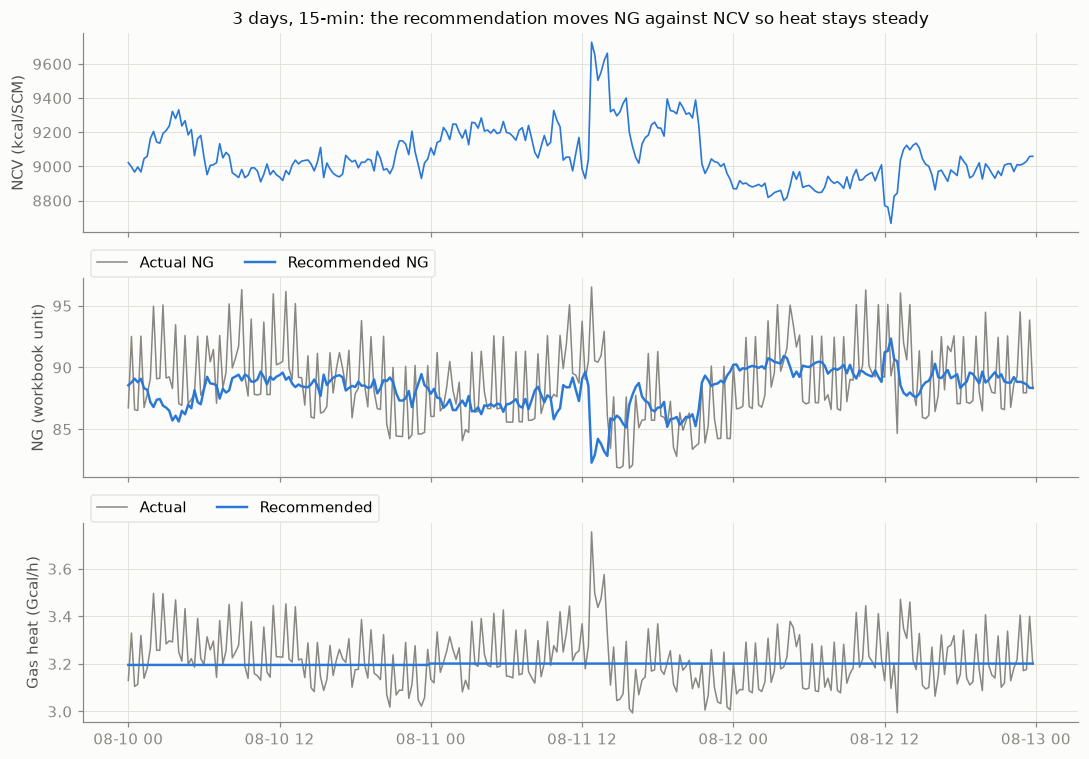

In [9]:
wk = bt_A.loc['2026-08-10':'2026-08-12']
fig, ax = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
ax[0].plot(wk.index, wk.ncv, color=BLUE, lw=1.1); ax[0].set_ylabel('NCV (kcal/SCM)')
ax[1].plot(wk.index, wk.ng_actual, color=MUTED, lw=1.0, label='Actual NG')
ax[1].plot(wk.index, wk.ng_rec, color=BLUE, lw=1.6, label='Recommended NG'); ax[1].set_ylabel('NG (workbook unit)'); ax[1].legend(loc='upper left', ncol=2, frameon=True, facecolor=SURF, edgecolor=GRID, bbox_to_anchor=(0, 1.18))
ax[2].plot(wk.index, wk.heat_actual*4/1e6, color=MUTED, lw=1.0, label='Actual')
ax[2].plot(wk.index, wk.heat_rec*4/1e6, color=BLUE, lw=1.6, label='Recommended'); ax[2].set_ylabel('Gas heat (Gcal/h)'); ax[2].legend(loc='upper left', ncol=2, frameon=True, facecolor=SURF, edgecolor=GRID, bbox_to_anchor=(0, 1.18))
ax[0].set_title('3 days, 15-min: the recommendation moves NG against NCV so heat stays steady')
plt.tight_layout(); plt.show()

The recommended NG moves exactly against NCV, so gas heat input stays flat at the day's target. Actual operation follows NCV only partly and also carries the reversal sawtooth.

## 6. Result per draw band and draw-adjusted (the two target views the client accepted)

In [10]:
base = u[u.in_baseline]
bins, labels = [45, 50, 55, 60, 65], ['45-50', '50-55', '55-60', '60-65']
band_base = base.groupby(pd.cut(base.draw_t, bins, labels=labels, include_lowest=True), observed=True).sfc.mean()
r = dA.copy(); r['band'] = pd.cut(r.draw_t, bins, labels=labels, include_lowest=True)
bt = r.groupby('band', observed=True).agg(days=('sfc', 'size'), actual=('sfc', 'mean'), recommended=('sfc_rec', 'mean'))
bt['baseline_band'] = band_base.reindex(bt.index); bt['target_2pct'] = bt.baseline_band * 0.98
bt['rec_vs_baseline_%'] = 100 * (bt.recommended / bt.baseline_band - 1)
bt['meets_target'] = bt.recommended <= bt.target_2pct
bt.round(1)

,days,actual,recommended,baseline_band,target_2pct,rec_vs_baseline_%,meets_target
band,,,,,,,
45-50,5,1769.9,1754.2,1765.9,1730.6,-0.7,False
50-55,18,1686.7,1686.0,1664.0,1630.8,1.3,False
55-60,33,1588.1,1570.4,1566.7,1535.4,0.2,False
60-65,29,1545.9,1531.0,1521.5,1491.1,0.6,False


In [11]:
mA = smf.ols('E_g ~ draw_t + cullet_pct', base).fit()      # draw-adjusted M&V model (nb03, Model A)
r = r.join(u[['cullet_pct']])
r['E_exp'] = mA.predict(r) * 1e6
r['act_vs_exp_%'] = 100 * (r.energy_kcal / r.E_exp - 1)
r['rec_vs_exp_%'] = 100 * ((r.gas_rec_day + r.elec_kcal) / r.E_exp - 1)
print('Draw-adjusted (energy vs baseline model at the same draw & cullet), Jun-Aug 2026:')
print('  actual       %+.2f%%' % r['act_vs_exp_%'].mean())
print('  recommended  %+.2f%%   (target: -2.00%%)' % r['rec_vs_exp_%'].mean())
def band_table(g):
    g = g.copy(); g['band'] = pd.cut(g.draw_t, bins, labels=labels, include_lowest=True)
    t = g.groupby('band', observed=True).agg(days=('sfc', 'size'), actual=('sfc', 'mean'), recommended=('sfc_rec', 'mean'))
    t['baseline_band'] = band_base.reindex(t.index); t['rec_vs_baseline_%'] = 100 * (t.recommended / t.baseline_band - 1)
    return t

Draw-adjusted (energy vs baseline model at the same draw & cullet), Jun-Aug 2026:
  actual       +1.14%
  recommended  +0.31%   (target: -2.00%)


## 7. Secondary air and AFR
The gas back-test above counts only gas heat. Air affects energy indirectly (extra air is heated and leaves through the flue). That effect is estimated from the daily relationship in nb03/T2: energy residual vs air per Mcal.

In [12]:
mB = smf.ols('E_g ~ draw_t + cullet_pct + age_m', u[u.in_baseline]).fit()
ma = smf.ols('resid ~ air_per_mcal', u.assign(resid=u.E_g - mB.predict(u))).fit()
air_saving = (ma.params.air_per_mcal * (te.air_per_mcal - AIR).clip(lower=0)).sum() / te.E_g.sum() * 100
print('Air per Mcal: actual median %.3f -> target median %.3f | estimated extra energy saving %.2f%%' % (te.air_per_mcal.median(), AIR.median(), air_saving))
print('Secondary air: actual median %.0f, recommended median %.0f | AFR actual %.2f, recommended %.2f (historical P1-P99 %.2f-%.2f)' % (
      bt_A.air_actual.median(), bt_A.air_rec.median(), bt_A.afr_actual.median(), bt_A.afr_rec.median(), *LIMITS['afr']))
pd.Series({'air_saving_pct': air_saving}).to_csv(dp.PROCESSED / 'nb04_air_saving.csv')

Air per Mcal: actual median 1.280 -> target median 1.269 | estimated extra energy saving 0.17%
Secondary air: actual median 1039, recommended median 1025 | AFR actual 12.17, recommended 11.93 (historical P1-P99 10.99-13.44)


## 8. Live use and Sep 2026 validation

In [13]:
# Example: what the operator would see now (inputs typed / read from DB)
example_day = test_days[-1]
print('Daily gas target for', example_day.date(), '= %.1f Gcal' % tgt[example_day])
rec = rc.recommend_gas(tgt[example_day], ncv_now=9200, air_per_mcal=AIR[example_day], limits=LIMITS)
print('NCV 9200 -> NG %.1f (workbook unit), AFR %.2f, secondary air %.0f' % (rec.ng_setpoint, rec.afr, rec.sec_air))
rec = rc.recommend_gas(tgt[example_day], ncv_now=9600, air_per_mcal=AIR[example_day], limits=LIMITS)
print('NCV 9600 -> NG %.1f (workbook unit), AFR %.2f, secondary air %.0f' % (rec.ng_setpoint, rec.afr, rec.sec_air))

Daily gas target for 2026-08-31 = 77.4 Gcal
NCV 9200 -> NG 87.6 (workbook unit), AFR 11.67, secondary air 1022
NCV 9600 -> NG 83.9 (workbook unit), AFR 12.17, secondary air 1022


### Sep 2026 validation (unseen month)
The same walk-forward back-test, run on September 2026. Every model choice was made on data up to August, so this month is a clean check. Each September day's target is fitted on all usable days before it.

In [14]:
sep_days = u[(u.index >= '2026-09-01') & (u.index <= '2026-09-30')].index
tgt_sep = rc.walk_forward_gas_targets(u, sep_days)
AIR_sep = pd.Series({day: rc.air_target(u, day) for day in sep_days})
ts_ = u.loc[sep_days]
bt_S = backtest(True, tgt_sep, sep_days, AIR_sep)
dS = daily_result(bt_S, 'Sep 2026').join(u[['cullet_pct']])
dS['E_exp'] = mA.predict(dS) * 1e6
sep_air = (ma.params.air_per_mcal * (ts_.air_per_mcal - AIR_sep).clip(lower=0)).sum() / ts_.E_g.sum() * 100
print('Sep 2026: %d usable days, mean draw %.1f t | 15-min recommendations %d, clipped %.1f%%' % (len(sep_days), ts_.draw_t.mean(), len(bt_S), 100*bt_S.clipped.mean()))
print('Target accuracy: pinball %.3f | share of days below target %.0f%% (25%% expected)' % (pinball(ts_.gas_g, tgt_sep), 100*(ts_.gas_g <= tgt_sep).mean()))
print('SFC: actual %.1f -> recommended %.1f  (saving %.2f%%) | + air estimate %.2f%%' % (dS.sfc.mean(), dS.sfc_rec.mean(), 100*(1 - dS.sfc_rec.mean()/dS.sfc.mean()), sep_air))
print('Draw-adjusted vs baseline: actual %+.2f%% -> recommended %+.2f%%' % (100*(dS.energy_kcal/dS.E_exp - 1).mean(), 100*((dS.gas_rec_day + dS.elec_kcal)/dS.E_exp - 1).mean()))
print('Optical in September: mean %.1f °C (Jun-Aug %.1f °C)' % (ts_.opt_f_prev.mean(), te.opt_f_prev.mean()))
display(target_scores(ts_.gas_g, ts_.E_g, [('chosen: OLS + ageing + conformal', tgt_sep),
        ('earlier: + previous-day optical', rc.walk_forward_gas_targets(u, sep_days, method='ols_conformal_opt')),
        ('first version: rolling QR 45d', rc.walk_forward_gas_targets(u, sep_days, method='qr_rolling'))]).round(3))
pd.Series({'air_saving_pct': air_saving, 'air_saving_pct_sep': sep_air}).to_csv(dp.PROCESSED / 'nb04_air_saving.csv')   # read by nb05
band_table(dS).round(1)

Sep 2026: 27 usable days, mean draw 57.2 t | 15-min recommendations 2556, clipped 0.1%
Target accuracy: pinball 0.326 | share of days below target 26% (25% expected)
SFC: actual 1610.4 -> recommended 1601.5  (saving 0.55%) | + air estimate 0.15%
Draw-adjusted vs baseline: actual +1.68% -> recommended +1.14%
Optical in September: mean 1573.1 °C (Jun-Aug 1574.4 °C)


,pinball,share of days below target,MAE (Gcal/day),implied energy saving %
chosen: OLS + ageing + conformal,0.326,0.259,0.901,0.539
earlier: + previous-day optical,0.386,0.407,0.843,0.155
first version: rolling QR 45d,0.476,0.333,1.228,0.599


,days,actual,recommended,baseline_band,rec_vs_baseline_%
band,,,,,
45-50,1,1744.0,1739.0,1765.9,-1.5
50-55,7,1700.1,1680.4,1664.0,1.0
55-60,12,1590.1,1581.1,1566.7,0.9
60-65,7,1536.5,1538.0,1521.5,1.1


**Reading (Sep 2026, unseen month)**
- **The chosen model holds its calibration:** 26% of days below target (25% intended) and its best accuracy score of any period (pinball 0.33).
- **Saving: 0.55% SFC** from gas (+0.15% from air), close to the 0.8% of Jun–Aug. Draw-adjusted, September moves from +1.68% to +1.14%. September started worse than the summer (+1.68% vs +1.14%), partly ageing (one more month).
- **The earlier version with previous-day optical fails here:** September's optical ran about 1.3 °C below the summer, so the optical term raised the target. 41% of days were already below it, and the saving dropped to 0.15%. This is why optical was removed from the model. Because that choice used September, the next clean check is October 2026 or the trial itself.
- **Per band**, every band improves except 60–65 t (flat), but none reaches −2% with gas alone. Notebook 05 adds the boost.

## 9. Summary
- **Model** (chosen in T1/T2, confirmed on Sep 2026):
  - **daily target:** OLS on all past usable days (draw, barrier and melter boost, furnace age), shifted to the 25th percentile of the last 45 days' errors
  - **every 15 min:** spread evenly over the day and divided by the latest NCV
  - **secondary air:** air-per-Mcal target (rolling P25) × heat; AFR = air ÷ NG
  - **optical:** a guard-rail input, not a model input (removed with the corrected data, §2 and §8)
- **Accuracy vs the first version:** pinball 0.36 vs 0.42 and daily error 1.0 vs 1.2 Gcal, at realistic coverage (20% of days below target in Jun–Aug, 26% in Sep; 25% expected).
- **Safety:** days already at or below the target had the same crown temperature, a lower MB3 and fewer seeds.
- **Saving, Jun–Aug 2026:** **0.81% SFC** (0.97% of gas) versus actual operation, plus an estimated **0.17%** from air. With and without historical limits give the same result, because no recommendation reached the NG limits.
- **Saving, Sep 2026 (validation):** **0.55% SFC** plus 0.15% from air.
- **Against the targets:** draw-adjusted, Jun–Aug moves from **+1.14%** to **+0.31%** and Sep from **+1.68%** to **+1.14%** with gas alone. Notebook 05 adds the boost lever and the combined result.